<center><font size=5><b>Extracting harmonics of $\phi$-dependent data in Gepard - The case of CLAS 2025 XUU</b></font></center>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [3]:
from scipy.optimize import curve_fit

In [4]:
import gdevel as gd
print(gd.__version__)

0.9.11


In [5]:
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "devel" and revision hash is 6a29f18c7246e4172fd8540814631d1b4fdb0f4a


In [6]:
#sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepardDevel/gdevel/src/gdevel')
import mydatafiles
from mydatafiles import ep2epgamma

mydset = gd.data.loaddata(mydatafiles)
mydset.update(gd.data.loaddata(ep2epgamma))

In [7]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 2.0)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [8]:
def plotFT(dfs, cosmax, sinmax):
    """Plot harmonics with with errorbars."""
    CM = cosmax
    SM = sinmax
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    shift = 0
    for df in dfs:
        c = df.val.values[:CM+1]
        delc = df.err.values[:CM+1]
        s = df.val.values[CM+1:CM+SM+1]
        dels = df.err.values[CM+1:CM+SM+1]
        ax.errorbar(np.arange(CM+1)+shift, c, delc, linestyle='None', capsize=3,color='blue')
        ax.errorbar(np.arange(-1,-SM-1,-1)+shift, s, dels, linestyle='None', capsize=3, color='red')
        shift += 0.05
    ax.axhline(linestyle='-.', color='green', linewidth=0.5)
    ax.axvline(linestyle='-.', color='green', linewidth=0.5)
    #ax.legend(loc=4, fontsize=14).draw_frame(1)
    fig.savefig('fig')

In [9]:
def csmax(N):
    """Returns largest cos and sin indices for N points in a bin."""
    cosmax = int((N-1)/2.)
    sinmax = cosmax + ((N-1) % 2)
    assert cosmax + sinmax == N - 1
    return (cosmax, sinmax)

In [10]:
# For check, we compare FT results to simple CLAS-like curve fit
def clasfit(df):
    """Fits A*sin(phi)/(1+B*cos(phi)) to a single xB-Q2-t bin in Pandas dataframe df."""
    # Define your model function
    def model_func(phi, A, B):
        return A * np.sin(phi) / (1 + B * np.cos(phi))
    
    # Assume your DataFrame is named df and has columns: 'phi', 'val', 'err'
    # Example: df = pd.DataFrame({'phi': ..., 'val': ..., 'err': ...})
    
    # Extract numpy arrays from DataFrame
    phi = df['phi'].values
    val = df['val'].values
    err = df['err'].values
    
    # Perform the fit using weights = 1/err^2
    popt, pcov = curve_fit(
        model_func,
        phi,
        val,
        sigma=err,
        absolute_sigma=True,  # use sigma to scale the covariance matrix
        p0=(1.0, 0.0)         # initial guesses for A and B
    )
    
    # Extract fit parameters and uncertainties
    A_fit, B_fit = popt
    A_err, B_err = np.sqrt(np.diag(pcov))
    
    # Print results
    # print(f"A = {A_fit:.6f} ± {A_err:.6f}")
    # print(f"B = {B_fit:.6f} ± {B_err:.6f}")
    return float(A_fit), float(A_err)

In [11]:
def gridplot(k):
    phis = np.linspace(-np.pi, np.pi, 80)  # used for sine curve
    
    fig, axes = plt.subplots(3, 3, figsize=[12, 12])
    axes = axes.flatten()
    
    for i in range(9):
        ki = k + i
        df = binS[ki]
        ax = axes[i]
        
        ax.errorbar(df.phi.values, df.val.values, df.err.values, color='blue',
                    linestyle='None', capsize=3)
        
        amp = df.iloc[0].FTval
        ax.plot(phis, amp * np.sin(phis), color='red', linestyle='solid', lw=2)
        
        ax.set_ylim(-1, 1)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_title(f'binS[{ki}]')
    
    plt.tight_layout()
    fig.savefig('fig_grid')

# Basic extraction of harmonics - Unpolirized cross section XUU (BSS)

In [12]:
ID = 166   # Gepard ID of a dataset

In [13]:
gd.describe_data(mydset[ID])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
1382 x XUU     CLAS    N/A    166 Priv comunication from Sangbaek
----------------------------------------------
TOTAL = 1382


We transform Gepard dataset into Pandas dataframe and take just some relevant columns.

In [14]:
dfS = mydset[ID].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

Gepard's FT routines below work with `err` as uncertainty to be FT-transformed. This
should be only statistical uncertainty, while systematic uncertainty should be added
in quadrature after FT (if you don't decide to do some even more sophisticated approach).
Thus, if data has separate `errstat` column we should rename it into `err`:

In [15]:
if 'err' in dfS.columns:
    dfS.rename(columns={'err': 'errtot'}, inplace=True)   # cannot have two err columns
dfS.rename(columns={'errstat': 'err'}, inplace=True)

In [16]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfS['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfS)]

# Initialize bin dictionary and list for bin centers
binS = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfS.iloc[start:end].copy().reset_index(drop=True)
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binS[k] = df_bin
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
Sbins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(Sbins)))

Number of all bins = 108


In [26]:
binS[2]

,Q2,xB,tm,in1energy,phi,val,errtot,err,errsyst,Q2_center,xB_center,tm_center
0,1.086,0.079,0.681,11,3.024167,3.41800,0.488857,0.225,0.434,1.086,0.079,0.681
1,1.086,0.079,0.681,11,2.766748,1.25100,0.409898,0.196,0.360,1.086,0.079,0.681
2,1.086,0.079,0.681,11,2.502785,0.69500,0.399516,0.117,0.382,1.086,0.079,0.681
3,1.086,0.079,0.681,11,2.053415,0.18580,0.393183,0.183,0.348,1.086,0.079,0.681
4,1.086,0.079,0.681,11,0.529149,0.05576,0.451426,0.267,0.364,1.086,0.079,0.681
5,1.086,0.079,0.681,11,0.000611,0.05628,0.484149,0.300,0.380,1.086,0.079,0.681
6,1.086,0.079,0.681,11,-1.061230,0.11510,0.462900,0.270,0.376,1.086,0.079,0.681
7,1.086,0.079,0.681,11,-1.596557,0.10620,0.420609,0.224,0.356,1.086,0.079,0.681
8,1.086,0.079,0.681,11,-2.412830,0.38920,0.386747,0.122,0.367,1.086,0.079,0.681
9,1.086,0.079,0.681,11,-2.767185,1.32100,0.515539,0.172,0.486,1.086,0.079,0.681


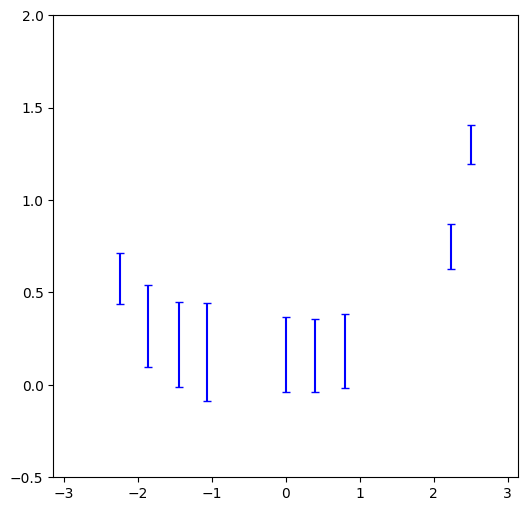

In [139]:
dfphi = binS[4]  # Some example bin
plotpts(dfphi)

In [144]:
cm=1; sm=0

In [145]:
dfFT = gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm)

In [146]:
dfFT.head(10)

,phi,val,err
0,2.502924,0.470999,0.061098
1,2.238106,-0.456718,0.092410
2,0.796097,0.000000,0.000000
3,0.394305,0.000000,0.000000
4,0.000611,0.000000,0.000000
5,-1.061579,0.000000,0.000000
6,-1.445133,0.000000,0.000000
7,-1.867642,0.000000,0.000000
8,-2.237599,0.000000,0.000000


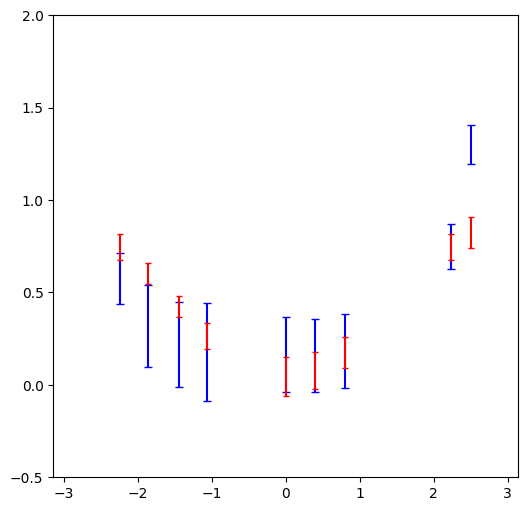

In [147]:
plotpts(dfphi, gd.data.FTFMC(gd.data.FTFMC(dfphi, cosmax=cm, sinmax=sm), inverse=True, cosmax=cm, sinmax=sm))

In [27]:
nc, ns = gd.data.FTanalyse(binS)

Highest extractable cos harmonic = 1.481 +- 0.739
Highest extractable sin harmonic = 0.565 +- 0.773



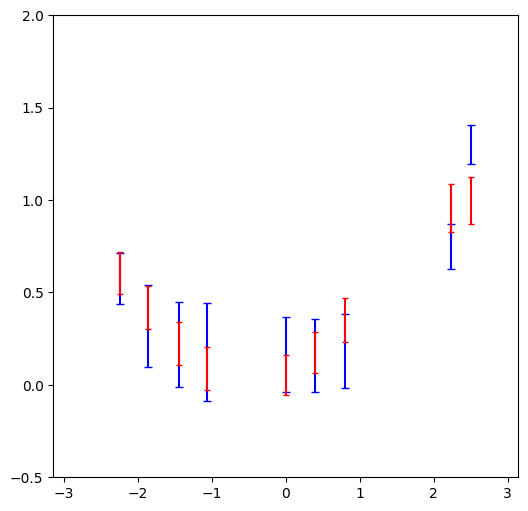

In [45]:
plotpts(binS[4], gd.data.FTFMC(gd.data.FTFMC(binS[4], cosmax=nc, sinmax=ns), inverse=True, cosmax=nc, sinmax=ns))

In [ ]:
nc = 1
ns = 0

for k in Sbins.index:
    bn = binS[k]
    dfFT = gd.data.FTFMC(bn, nsamples=3000, cosmax=nc, sinmax=ns)
    if len(dfFT) >= 1:  # at least 2 armonics
        for typ in ('val', 'err'):
            bn[f'FT{typ}'] = pd.Series(dfFT[typ].values[:len(bn)], index=bn.index)
    else:
        print(f"Bin {k} skipped: not enough data for cos1.")

def c0(bin):
    return bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[0]

def c1(bin):
    #if len(bin) < 2:
    #    return None
    return bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[1]

#def c2(bin):
    #if len(bin) < 3:
    #    return None
#    return bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[2]

FTc0 = pd.DataFrame([c0(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc0['FTn'] = 0

FTc1 = pd.DataFrame([c1(binS[k]) for k in Sbins.index]).reset_index(drop=True)
FTc1['FTn'] = 1

#FTc2 = pd.DataFrame([c2(binS[k]) for k in Sbins.index]).reset_index(drop=True)
#FTc2['FTn'] = 2

In [60]:
print(FTc0[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

   xB    Q2    tm  FTn      FTval       FTerr
0.072 1.091 0.130    0  -3.067174    0.757307
0.084 1.085 0.446    0   0.600762    0.052747
0.079 1.086 0.681    0   0.438733    0.081001
0.079 1.296 0.215    0   0.901475    0.191933
0.086 1.271 0.455    0   0.513536    0.058746
0.101 1.101 0.129    0  -0.163157    0.494789
0.101 1.096 0.516    0   0.261490    0.096779
0.110 1.103 0.648    0   0.507159    0.161315
0.101 1.335 0.129    0   3.805433    0.108481
0.100 1.337 0.198    0   0.393444    0.126717
0.103 1.317 0.494    0   0.443767    0.049600
0.110 1.299 0.652    0   0.180589    0.078998
0.104 1.628 0.129    0   3.765597    0.052787
0.103 1.625 0.201    0   2.306513    0.029696
0.102 1.633 0.328    0   0.706683    0.031987
0.109 1.605 0.473    0   0.352927    0.039829
0.109 1.599 0.674    0   0.136257    0.063055
0.133 1.328 0.129    0   0.969644    0.074615
0.131 1.327 0.516    0   0.317716    0.076236
0.134 1.302 0.705    0   0.078015    0.136656
0.132 1.697 0.129    0   1.123574 

In [61]:
print(FTc1[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

   xB    Q2    tm  FTn      FTval       FTerr
0.072 1.091 0.130    1   6.817865    1.147710
0.084 1.085 0.446    1  -0.706089    0.082371
0.079 1.086 0.681    1  -0.866854    0.108326
0.079 1.296 0.215    1  -0.299677    0.331535
0.086 1.271 0.455    1  -0.571067    0.092780
0.101 1.101 0.129    1   1.211497    0.782925
0.101 1.096 0.516    1  -0.291446    0.154045
0.110 1.103 0.648    1  -1.155655    0.247878
0.101 1.335 0.129    1  -3.452475    0.162582
0.100 1.337 0.198    1   0.159858    0.223145
0.103 1.317 0.494    1  -0.779808    0.062641
0.110 1.299 0.652    1  -0.340932    0.109293
0.104 1.628 0.129    1  -4.845742    0.079941
0.103 1.625 0.201    1  -3.374833    0.051879
0.102 1.633 0.328    1  -0.855194    0.056453
0.109 1.605 0.473    1  -0.562856    0.057431
0.109 1.599 0.674    1  -0.225261    0.077485
0.133 1.328 0.129    1  -1.272114    0.105986
0.131 1.327 0.516    1  -0.919908    0.086455
0.134 1.302 0.705    1  -0.122183    0.214837
0.132 1.697 0.129    1  -1.074298 

In [62]:
print(FTc2[['xB', 'Q2', 'tm', 'FTn', 'FTval', 'FTerr']].to_string(index=False))

   xB    Q2    tm  FTn      FTval       FTerr
0.072 1.091 0.130    2  -2.428505    0.444401
0.084 1.085 0.446    2   0.388821    0.085780
0.079 1.086 0.681    2   0.826363    0.110673
0.079 1.296 0.215    2   0.086885    0.190647
0.086 1.271 0.455    2   0.302476    0.126480
0.101 1.100 0.198    2  -0.658920    0.345376
0.101 1.096 0.516    2   0.127632    0.163206
0.110 1.103 0.648    2   0.790503    0.192031
0.101 1.335 0.129    2   0.092671    0.177740
0.100 1.337 0.198    2  -0.218903    0.133389
0.103 1.317 0.494    2   0.584386    0.073015
0.110 1.299 0.652    2   0.281110    0.105197
0.104 1.628 0.129    2   2.757704    0.071827
0.103 1.625 0.201    2   2.296860    0.055856
0.102 1.633 0.328    2   0.447629    0.069580
0.109 1.605 0.473    2   0.412523    0.064584
0.109 1.599 0.674    2   0.179310    0.100685
0.133 1.328 0.129    2   0.630654    0.093285
0.131 1.327 0.516    2   0.938188    0.097557
0.134 1.302 0.705    2   0.066216    0.196510
0.132 1.697 0.129    2   0.440676 

In [70]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# --- Define the CLAS-like cosine model ---
def clasfit_unpolarized(df):
    """Fit c0 + c1*cos(phi) + c2*cos(2phi) to unpolarized cross section data."""
    
    def model_func(phi, c0, c1, c2):
        return c0 + c1 * np.cos(phi) + c2 * np.cos(2*phi)

    phi = df['phi'].values
    val = df['val'].values
    err = df['err'].values

    popt, pcov = curve_fit(
        model_func,
        phi,
        val,
        sigma=err,
        absolute_sigma=True,
        p0=(1.0, 0.1, 0.05)  # reasonable initial guesses
    )

    c0, c1, c2 = popt
    dc0, dc1, dc2 = np.sqrt(np.diag(pcov))

    return (c0, dc0), (c1, dc1), (c2, dc2)


In [148]:
for k, bn in binS.items():
    try:
        (c0_fit, dc0_fit), (c1_fit, dc1_fit), (c2_fit, dc2_fit) = clasfit_unpolarized(bn)

        c0_FT, dc0_FT = bn.FTval.iloc[0], bn.FTerr.iloc[0]
        c1_FT, dc1_FT = bn.FTval.iloc[1], bn.FTerr.iloc[1]
        c2_FT, dc2_FT = bn.FTval.iloc[2], bn.FTerr.iloc[2]

        n0 = abs(c0_fit - c0_FT) / dc0_FT
        n1 = abs(c1_fit - c1_FT) / dc1_FT
        n2 = abs(c2_fit - c2_FT) / dc2_FT

        if n0 > 1.5 or n1 > 1.5 or n2 > 1.5:
            print(f"bin {k}: Δc0 = {n0:.1f} sigmas, Δc1 = {n1:.1f} sigmas, Δc2 = {n2:.1f} sigmas (row {k+63})")
    except Exception as e:
        print(f"bin {k}: fit failed → {e}")


bin 0: Δc0 = 3.1 sigmas, Δc1 = 3.1 sigmas, Δc2 = 3.3 sigmas (row 63)
bin 2: Δc0 = 1.4 sigmas, Δc1 = 2.3 sigmas, Δc2 = 0.4 sigmas (row 65)
bin 8: Δc0 = 2.7 sigmas, Δc1 = 3.2 sigmas, Δc2 = 4.1 sigmas (row 71)
bin 9: Δc0 = 1.6 sigmas, Δc1 = 1.7 sigmas, Δc2 = 1.3 sigmas (row 72)
bin 10: Δc0 = 2.0 sigmas, Δc1 = 1.1 sigmas, Δc2 = 1.1 sigmas (row 73)
bin 12: Δc0 = 3.1 sigmas, Δc1 = 6.2 sigmas, Δc2 = 0.1 sigmas (row 75)
bin 13: Δc0 = 15.6 sigmas, Δc1 = 17.4 sigmas, Δc2 = 11.4 sigmas (row 76)
bin 14: Δc0 = 1.0 sigmas, Δc1 = 1.2 sigmas, Δc2 = 1.7 sigmas (row 77)
bin 15: Δc0 = 2.2 sigmas, Δc1 = 2.2 sigmas, Δc2 = 0.8 sigmas (row 78)
bin 17: Δc0 = 0.1 sigmas, Δc1 = 2.3 sigmas, Δc2 = 2.6 sigmas (row 80)
bin 18: Δc0 = 0.3 sigmas, Δc1 = 0.1 sigmas, Δc2 = 2.0 sigmas (row 81)
bin 20: Δc0 = 1.1 sigmas, Δc1 = 0.5 sigmas, Δc2 = 2.6 sigmas (row 83)
bin 21: Δc0 = 1.4 sigmas, Δc1 = 0.9 sigmas, Δc2 = 1.6 sigmas (row 84)
bin 22: Δc0 = 4.4 sigmas, Δc1 = 1.6 sigmas, Δc2 = 3.0 sigmas (row 85)
bin 23: Δc0 = 1.4 sig

In [94]:
def plot_clasfit_unpolarized(df, title=""):
    phi_fit = np.linspace(-np.pi, np.pi, 300)

    (c0, _), (c1, _), (c2, _) = clasfit_unpolarized(df)
    model = c0 + c1 * np.cos(phi_fit) + c2 * np.cos(2*phi_fit)

    fig, ax = plt.subplots()
    ax.errorbar(df['phi'], df['val'], yerr=df['err'], fmt='o', label='Data', color='black')
    ax.plot(phi_fit, model, label='CLAS fit', color='red')
    ax.set_xlabel(r'$\phi$')
    ax.set_ylabel('')
    ax.set_title(title)
    ax.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

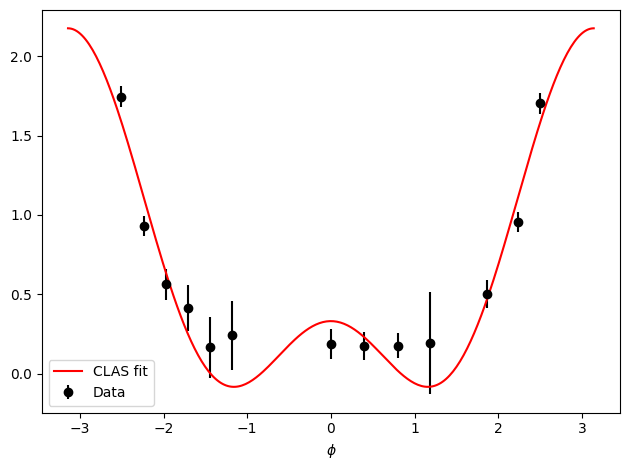

In [95]:
plot_clasfit_unpolarized(binS[14])